Cell 1

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


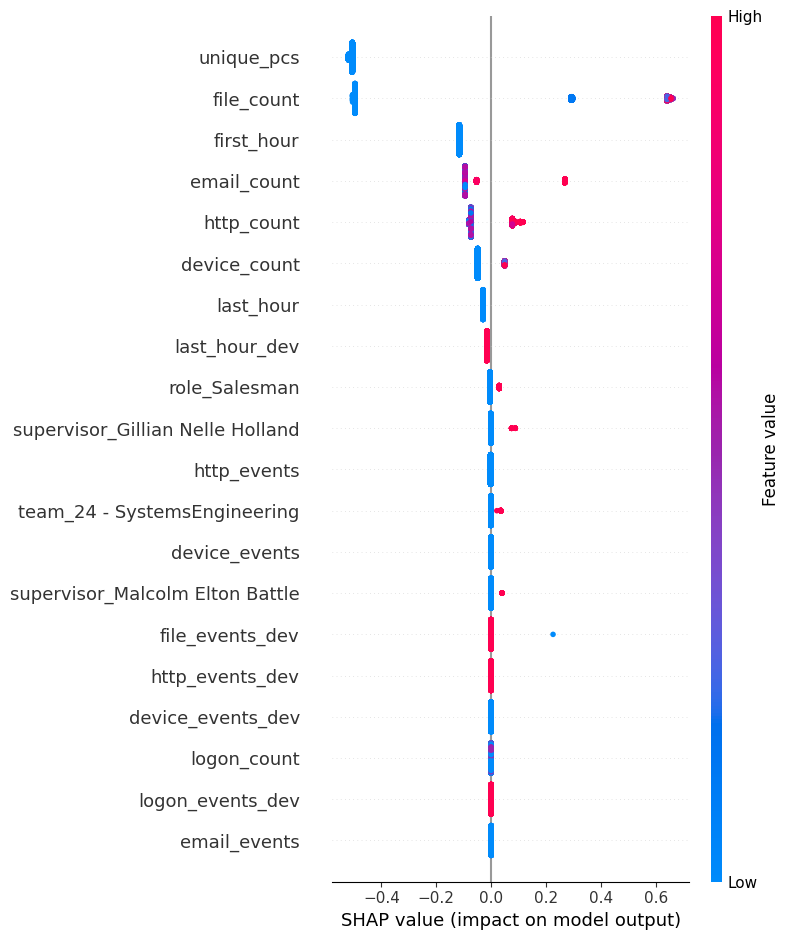

<Figure size 640x480 with 0 Axes>

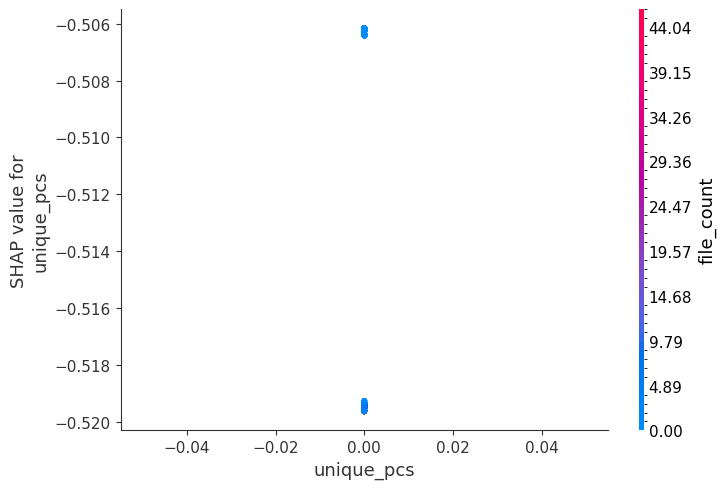

<Figure size 640x480 with 0 Axes>

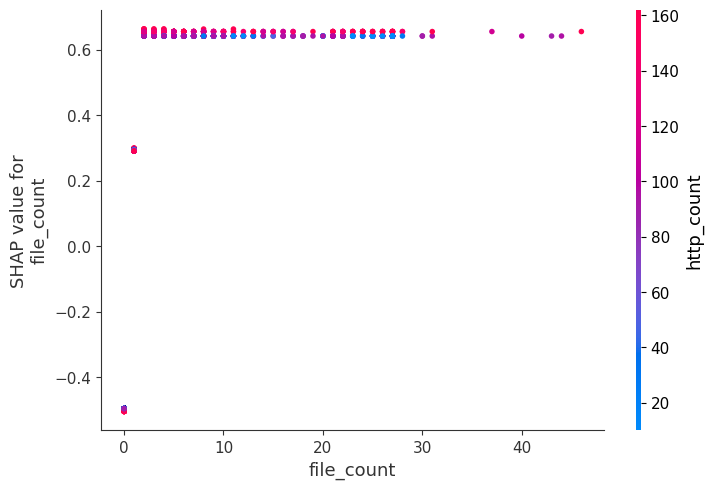

<Figure size 640x480 with 0 Axes>

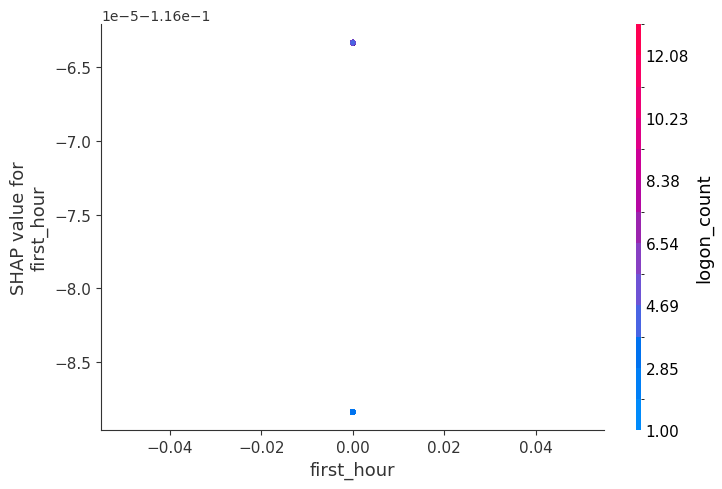

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Figure size 640x480 with 0 Axes>

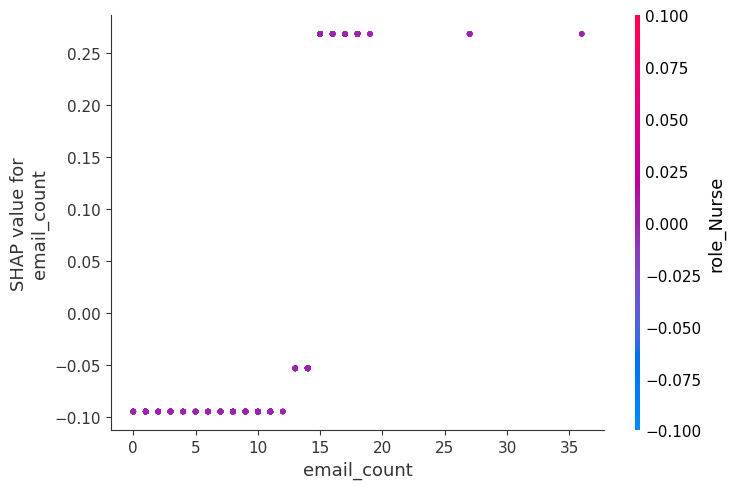

<Figure size 640x480 with 0 Axes>

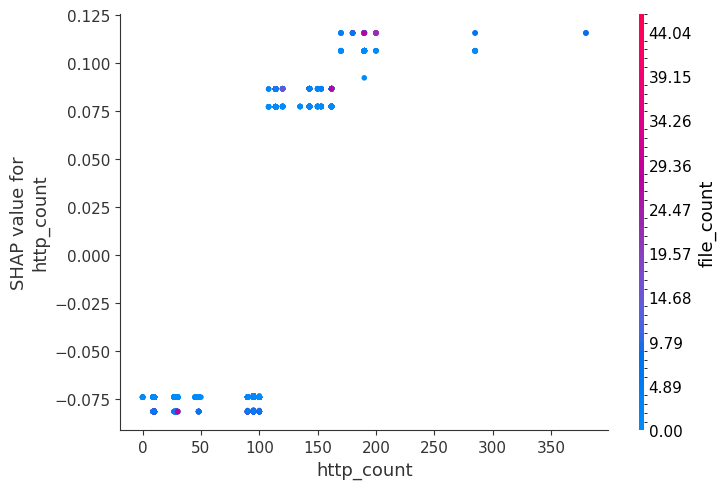

<Figure size 640x480 with 0 Axes>

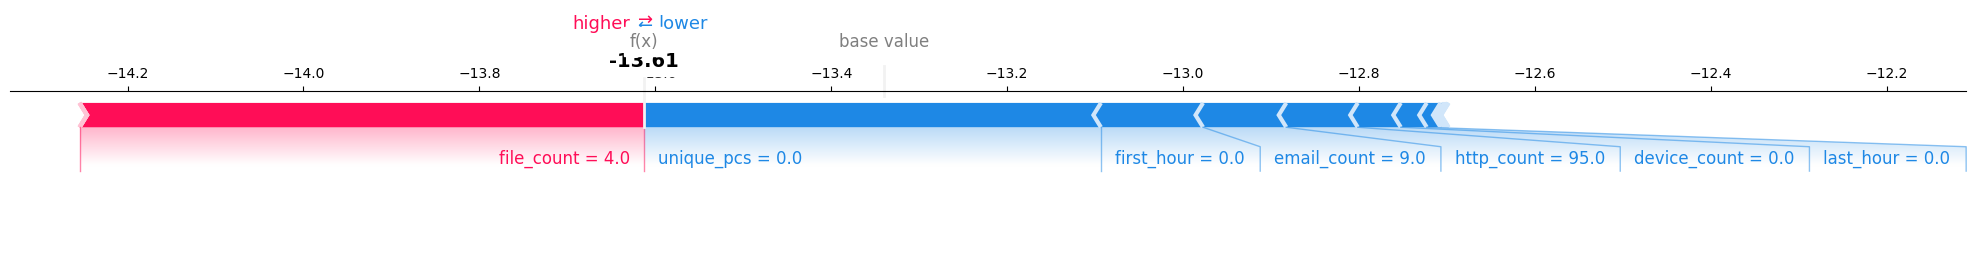

Done
unique_pcs                          0.509124
file_count                          0.503569
first_hour                          0.116087
email_count                         0.109521
http_count                          0.076717
device_count                        0.048998
last_hour                           0.029510
last_hour_dev                       0.015627
role_Salesman                       0.006227
supervisor_Gillian Nelle Holland    0.001690
http_events                         0.001505
team_24 - SystemsEngineering        0.001211
device_events                       0.000656
supervisor_Malcolm Elton Battle     0.000435
file_events_dev                     0.000376
dtype: float32


In [1]:
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

model_path = "data/models/xgb_temporal.joblib"
data_path = "data/processed/feature_df.parquet"

model = joblib.load(model_path)
df = pd.read_parquet(data_path)

leak_cols = [
    "after_hours_events",
    "user_mean_after",
    "user_std_after",
    "after_hours_events_dev",
    "after_hours_ratio",
]
mean_std_cols = [c for c in df.columns if c.startswith("user_mean_") or c.startswith("user_std_")]
# drop_cols = list(set(leak_cols + mean_std_cols + ["user", "day", "employee_name", "email", "projects"]))
drop_cols = list(set(leak_cols + mean_std_cols + ["user", "day", "employee_name", "email", "projects", "total_events"]))

df = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

y = df.pop("is_insider").astype(int)

cat_cols = [c for c in ["role", "functional_unit", "department", "team", "supervisor"] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

X = df.copy()
if "is_insider" in X.columns:
    y = X.pop("is_insider")
else:
    y = None

if hasattr(model, "feature_names_in_"):
    feat_cols = list(model.feature_names_in_)
    X = X[feat_cols]

sample_n = min(5000, len(X))
X_sample = X.sample(sample_n, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values_to_use = shap_values[-1]
    expected_value = explainer.expected_value[-1]
else:
    shap_values_to_use = shap_values
    expected_value = explainer.expected_value

shap_df = pd.DataFrame(shap_values_to_use, columns=X_sample.columns, index=X_sample.index)
shap_df.to_csv("data/processed/shap_values.csv")

mean_abs = shap_df.abs().mean().sort_values(ascending=False)
mean_abs.to_csv("data/processed/shap_global_importance.csv", header=["mean_abs_shap"])

plt.figure()
shap.summary_plot(shap_values_to_use, X_sample, show=False, max_display=20)
plt.tight_layout()
plt.savefig("data/visualizations/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
# plt.close()

top_feats = mean_abs.head(5).index.tolist()
for feat in top_feats:
    plt.figure()
    shap.dependence_plot(feat, shap_values_to_use, X_sample, show=False)
    plt.tight_layout()
    plt.savefig(f"data/visualizations/dependence_{feat}.png", dpi=300, bbox_inches="tight")
    plt.show()
    # plt.close()

row_idx = X_sample.index[0]
plt.figure()
shap.force_plot(expected_value, shap_values_to_use[0, :], X_sample.iloc[0, :], matplotlib=True, show=False)
plt.tight_layout()
plt.savefig("data/visualizations/force_plot_row0.png", dpi=300, bbox_inches="tight")
plt.show()
# plt.close()

print("Done")
print(mean_abs.head(15))

SHAP bar chart

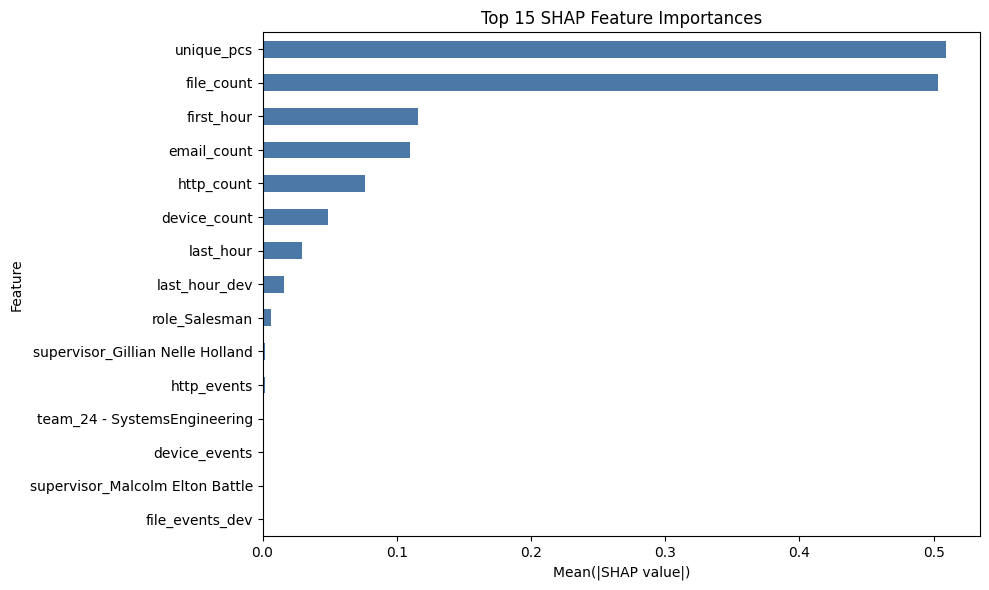

unique_pcs                          0.509124
file_count                          0.503569
first_hour                          0.116087
email_count                         0.109521
http_count                          0.076717
device_count                        0.048998
last_hour                           0.029510
last_hour_dev                       0.015627
role_Salesman                       0.006227
supervisor_Gillian Nelle Holland    0.001690
http_events                         0.001505
team_24 - SystemsEngineering        0.001211
device_events                       0.000656
supervisor_Malcolm Elton Battle     0.000435
file_events_dev                     0.000376
dtype: float32

In [2]:
top15 = mean_abs.head(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind="barh", color="#4C78A8")
plt.xlabel("Mean(|SHAP value|)")
plt.ylabel("Feature")
plt.title("Top 15 SHAP Feature Importances")
plt.tight_layout()
plt.savefig("data/visualizations/shap_bar_top15.png", dpi=300, bbox_inches="tight")
plt.show()

top15.to_csv("data/processed/shap_bar_top15.csv", header=["mean_abs_shap"])
top15